Name:SHREYA S HIRAVE [3064]


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten the images for the autoencoder
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# One-hot encode the labels for classification
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Define the input shape
input_dim = 28 * 28
encoding_dim = 64  # Dimension of the encoded representation

# Encoder
input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [4]:
# Train the autoencoder
autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.3232 - val_loss: 0.1417
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1327 - val_loss: 0.1110
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1096 - val_loss: 0.1005
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.1002 - val_loss: 0.0954
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0953 - val_loss: 0.0917
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0913 - val_loss: 0.0885
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0887 - val_loss: 0.0861
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0866 - val_loss: 0.0844
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0850 - val_loss: 0.0837
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0836 - val_loss: 0.0820


In [5]:
# Extract the encoder model
encoder = Model(input_img, encoded)

# Generate encoded features
X_train_encoded = encoder.predict(X_train_flat)
X_test_encoded = encoder.predict(X_test_flat)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [6]:
# Define the classifier
classifier_input = Input(shape=(encoding_dim,))
classifier_output = Dense(64, activation='relu')(classifier_input)
classifier_output = Dense(10, activation='softmax')(classifier_output)

# Classifier model
classifier = Model(classifier_input, classifier_output)

# Compile the classifier
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
# Train the classifier on encoded features
classifier.fit(
    X_train_encoded, y_train_onehot,
    epochs=10,
    batch_size=256,
    validation_data=(X_test_encoded, y_test_onehot)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3549 - loss: 3.2022 - val_accuracy: 0.8114 - val_loss: 0.6203
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8285 - loss: 0.5634 - val_accuracy: 0.8822 - val_loss: 0.4078
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8832 - loss: 0.3954 - val_accuracy: 0.9015 - val_loss: 0.3410
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.3414 - val_accuracy: 0.9117 - val_loss: 0.3070
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9094 - loss: 0.3080 - val_accuracy: 0.9179 - val_loss: 0.2860
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9146 - loss: 0.2901 - val_accuracy: 0.9222 - val_loss: 0.2713
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9212 - loss: 0.2696 - val_accuracy: 0.9252 - val_loss: 0.2603
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9255 - loss: 0.2571 - val_accuracy: 0.

In [8]:
# Evaluate the classifier on test data
loss, accuracy = classifier.evaluate(X_test_encoded, y_test_onehot, verbose=0)
print(f"Classifier Test Accuracy: {accuracy:.4f}")

Classifier Test Accuracy: 0.9310


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


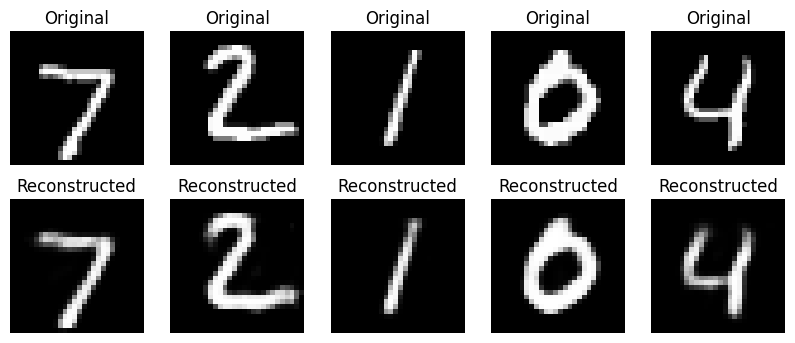

In [9]:
# Visualize some original and reconstructed images
decoded_imgs = autoencoder.predict(X_test_flat)

n = 5  # Number of images to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


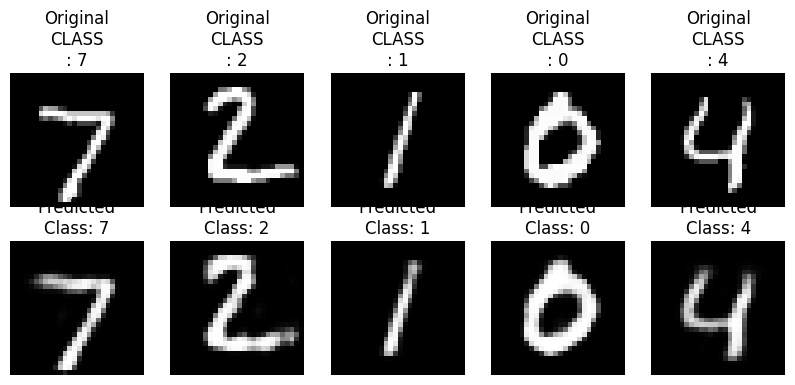

In [36]:

# Visualize some original and reconstructed images with class labels
decoded_imgs = autoencoder.predict(X_test_flat)

n = 5  # Number of images to display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Original\nCLASS\n: {y_test[i]}") # Display class label
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')

    # Predict the class label for the reconstructed image
    predicted_class = np.argmax(classifier.predict(encoder.predict(X_test_flat[i:i+1])), axis=1)[0]
    plt.title(f"Predicted\nClass: {predicted_class}") # Display predicted class
    plt.axis('off')
plt.show()
